In [ ]:
#Section 1: Installation
!pip install -q open_clip_torch sentence-transformers pandas scikit-learn seaborn matplotlib easyocr transformers
!wget -q https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 26.8 MB/s eta 0:00:00


In [ ]:
#Section 2: Data Preparation
import os
import torch
import open_clip
import easyocr
import pandas as pd
import numpy as np
import glob
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_recall_fscore_support, fbeta_score
from transformers import AutoTokenizer


In [ ]:
# Configure Thai Font
fm.fontManager.addfont('Sarabun-Regular.ttf')
plt.rc('font', family='Sarabun')

# Unzip data
if os.path.exists("Data.zip"):
    !unzip -q Data.zip -d merchant_data
    if os.path.exists("merchant_data/Data"):
        DATA_ROOT = "merchant_data/Data"
    else:
        DATA_ROOT = "merchant_data"
else:
    print("Data.zip not found")
    DATA_ROOT = "merchant_data"

In [ ]:
#Section 3: Define Category + Helper Function
#Define Category
CATEGORY_MAP = {
    "ช้อปปิ้ง": ["ของที่ระลึก กรอบรูป", "ของสะสม และของเล่น", "คอมพิวเตอร์และอุปกรณ์ต่อพ่วงคอมพิวเตอร์และซอฟต์แวร์", "เครื่องใช้ไฟฟ้า และอุปกรณ์ไฟฟ้า", "เครื่องสำอางค์", "ผลิตภัณฑ์ดูแลสุขภาพ", "ร้านกิฟต์ชอป, ร้านของชําร่วย", "ร้านขายของชำ โชห่วย และซูเปอร์มาร์เก็ต", "ร้านขายของสด หรือ เนื้อสัตว์แช่แข็ง", "ร้านขายสินค้าเบ็ตเตล็ด", "ร้านค้าส่ง", "ร้านรองเท้า กระเป๋า เครื่องหนัง", "ร้านอะไหล่รถยนต์และอุปกรณ์เสริม", "วัสดุก่อสร้าง", "แว่นตาและสินค้าออฟติคอล", "สัตว์เลี้ยง อาหารสัตว์เลี้ยง และอุปกรณ์สำหรับสัตว์เลี้ยง", "สินค้าเกษตร", "สินค้าดิจิทัล - แอปพลิเคชัน (ไม่รวมเกม)", "เสื้อผ้าและเครื่องประดับ", "อุปกรณ์ทำสวน ดอกไม้ ต้นไม้"],
    "ท่องเที่ยว": ["ที่พัก – โรงแรม รีสอร์ท"],
    "บริการต่างๆ": ["การถ่ายภาพเชิงพาณิชย์ ศิลปะ และกราฟิก ", "จัดสวนและทำสวน", "ช่างทำกุญแจ", "ซ่อมนาฬิกา และเครื่องประดับ", "ถ่ายเอกสาร คัดลอกสำเนา รับพิมพ์นามบัตร และรับพิมพ์งานต่าง", "บริการจัดเลี้ยง", "บริการซ่อมคอมพิวเตอร์", "บริการซัก อบ รีดและตัดเย็บเสื้อผ้า", "บริการส่งจดหมาย ส่งพัสดุ", "บริการสัตวแพทย์และบริการที่เกี่ยวกับสัตว์เลี้ยง", "รับซ่อมต่างๆ", "ร้านขายยางและซ่อมยางรถยนต์", "ร้านซ่อมเครื่องใช้ไฟฟ้า", "ร้านล้างรถ"],
    "บันเทิง": ["สันทนาการต่างๆ"],
    "สุขภาพและความงาม": ["คลินิก หรือสถานพยาบาล", "นวดแผนไทยและสปาสุขภาพ", "นักทัศนมาตรและจักษุแพทย์", "ร้านขายยา", "ร้านเสริมสวยและร้านทำผม", "สถาบันเสริมความงามและศัลยกรรม"],
    "อาหารและเครื่องดื่ม": ["ขนม ของทานเล่น", "เบเกอรี่ / ของหวาน / ไอศกรีม", "ร้านขายผลไม้", "ร้านเครื่องดื่ม / คาเฟ่", "ร้านอาหาร", "อาหารจานด่วน"]
}

# 2. Helper: Flatten Subcategories & Reverse Map
ALL_SUBCATEGORIES = []
SUBCAT_TO_CAT_MAP = {}

for cat, subcats in CATEGORY_MAP.items():
    for sub in subcats:
        ALL_SUBCATEGORIES.append(sub)
        SUBCAT_TO_CAT_MAP[sub] = cat

OCR_KEYWORDS = {
    "อาหารและเครื่องดื่ม": ["อาหาร", "coffee", "cafe", "ก๋วยเตี๋ยว", "ข้าว", "bakery", "ขนม", "drink", "restaurant", "หมู", "ไก่", "อร่อย", "ตำ", "ยำ", "tea", "bistro"],
    "สุขภาพและความงาม": ["คลินิก", "clinic", "ทันตกรรม", "นวด", "massage", "spa", "สปา", "ยา", "pharmacy", "เภสัช", "ตัดผม", "salon", "beauty", "hair", "nail", "ทำเล็บ"],
    "บริการต่างๆ": ["ซ่อม", "service", "ล้าง", "wash", "ขนส่ง", "express", "ถ่ายเอกสาร", "print", "ซัก", "laundry", "โรงเรียน", "school", "ติว", "garage", "tutor"],
    "ท่องเที่ยว": ["hotel", "resort", "โรงแรม", "รีสอร์ท", "ที่พัก", "inn", "hostel", "room"],
    "ช้อปปิ้ง": ["shop", "store", "market", "ขาย", "จำหน่าย", "mart", "วัสดุ", "ก่อสร้าง", "fashion", "gift", "seven", "eleven", "lotus", "bigc"],
    "บันเทิง": ["karaoke", "คาราโอเกะ", "snooker", "game", "club", "bar", "pub"]
}

In [ ]:
#Section 4: Load Model
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load mCLIP Model (xlm-roberta-large-ViT-H-14)
model, _, preprocess = open_clip.create_model_and_transforms(
    'xlm-roberta-large-ViT-H-14',
    pretrained='frozen_laion5b_s13b_b90k' # openCLIP pre-trained model
)
model = model.to(device)
model.eval()

# Load Thai Tokenizer
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-large') # add Multilingual to openCLIP

# Load OCR Model
reader = easyocr.Reader(['th', 'en'], gpu=(device=='cuda'), verbose=False)

# Pre-compute Text Embeddings
with torch.no_grad():
    text_inputs = tokenizer(
        ALL_SUBCATEGORIES,
        padding="max_length",
        max_length = 77,
        truncation=True,
        return_tensors="pt"
    ).to(device)

    # Encode text
    text_features = model.encode_text(text_inputs.input_ids)
    text_features /= text_features.norm(dim=-1, keepdim=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_pytorch_model.bin:   0%|          | 0.00/4.77G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [ ]:
#Section 5: Run Model
CSV_PATH = "data.csv"

if not os.path.exists(CSV_PATH):
    print(f"Error: {CSV_PATH} not found.")
else:
    df = pd.read_csv(CSV_PATH)
    results = []

    for index, row in df.iterrows():
        shop_id = str(row['Shop_ID'])

        shop_folder = os.path.join(DATA_ROOT, shop_id)
        if not os.path.exists(shop_folder):
            shop_folder = os.path.join(DATA_ROOT, "Data", shop_id)

        # Get Images
        image_paths = []
        if os.path.exists(shop_folder):
            all_files = glob.glob(os.path.join(shop_folder, "*"))
            image_paths = [p for p in all_files if p.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))]

        # Default values
        predicted_cat = "ช้อปปิ้ง"
        predicted_sub = "Unknown"
        confidence = 0.0
        ocr_text_log = ""
        category_scores_log = {}

        if image_paths:
            # mCLIP Encoding
            proc_images = image_paths[:4]
            img_tensors = []

            for img_p in proc_images:
                try:
                    img = Image.open(img_p).convert("RGB")
                    img_tensors.append(preprocess(img).unsqueeze(0))
                except:
                    continue

            if img_tensors:
                img_batch = torch.cat(img_tensors).to(device)

                with torch.no_grad():
                    image_features = model.encode_image(img_batch)
                    image_features /= image_features.norm(dim=-1, keepdim=True)
                    shop_vector = image_features.mean(dim=0, keepdim=True)

                    # Softmax Logits
                    clip_logits = (100.0 * shop_vector @ text_features.T)
                    clip_probs = clip_logits.softmax(dim=-1).cpu().numpy()[0]

                # Base Score from mCLIP
                category_scores = {cat: 0.0 for cat in CATEGORY_MAP.keys()}
                for idx, sub_name in enumerate(ALL_SUBCATEGORIES):
                    parent = SUBCAT_TO_CAT_MAP[sub_name]
                    if clip_probs[idx] > category_scores[parent]:
                        category_scores[parent] = clip_probs[idx]

                # OCR
                detected_words = []
                for img_p in proc_images[:4]:
                    try:
                        res = reader.readtext(img_p, detail=0, paragraph=True)
                        detected_words.extend(res)
                    except:
                        pass

                full_text = " ".join(detected_words).lower()
                ocr_text_log = full_text[:100]

                # OCR Boost
                for cat, keywords in OCR_KEYWORDS.items():
                    for kw in keywords:
                        if kw in full_text:
                            category_scores[cat] += 0.35
                            break

                total = sum(category_scores.values())
                if total > 0:
                  category_scores = {k: v / total for k, v in category_scores.items()}

                # Final Decision
                best_cat = max(category_scores, key=category_scores.get)

                best_sub_score = -1
                best_sub = ""
                for idx, sub_name in enumerate(ALL_SUBCATEGORIES):
                    if SUBCAT_TO_CAT_MAP[sub_name] == best_cat:
                        if clip_probs[idx] > best_sub_score:
                            best_sub_score = clip_probs[idx]
                            best_sub = sub_name

                predicted_cat = best_cat
                predicted_sub = best_sub
                confidence = category_scores[best_cat]

                # Save Raw Category Scores
                category_scores_log = {k: round(v, 4) for k, v in category_scores.items()}

        # Append Result
        results.append({
            "Shop_ID": shop_id,
            "True_Category": row['TrueCategory'],
            "Original_Category": row['Category'],
            "Predicted_Category": predicted_cat,
            "Predicted_Subcategory": predicted_sub,
            "Confidence": confidence,
            "Category_Scores": str(category_scores_log),
            "OCR_Log": ocr_text_log
        })

        if (index + 1) % 10 == 0:
            print(f"Processed {index + 1}/{len(df)}")

    # Save Results
    result_df = pd.DataFrame(results)
    result_df.to_csv("submission_results.csv", index=False)
    print("Finished")

Processed 10/76
Processed 20/76
Processed 30/76
Processed 40/76
Processed 50/76
Processed 60/76
Processed 70/76
Finished


            MODEL PERFORMANCE EVALUATION REPORT             

📊 1. EXECUTIVE SUMMARY
---------------------------------------------
• Total Samples Evaluated:    76
• Global Accuracy:            65.79%
• Macro F1-Score:             0.3993
• Macro F2-Score:             0.4055
• Weighted F1-Score:          0.6302
• Weighted F2-Score:          0.6411
---------------------------------------------


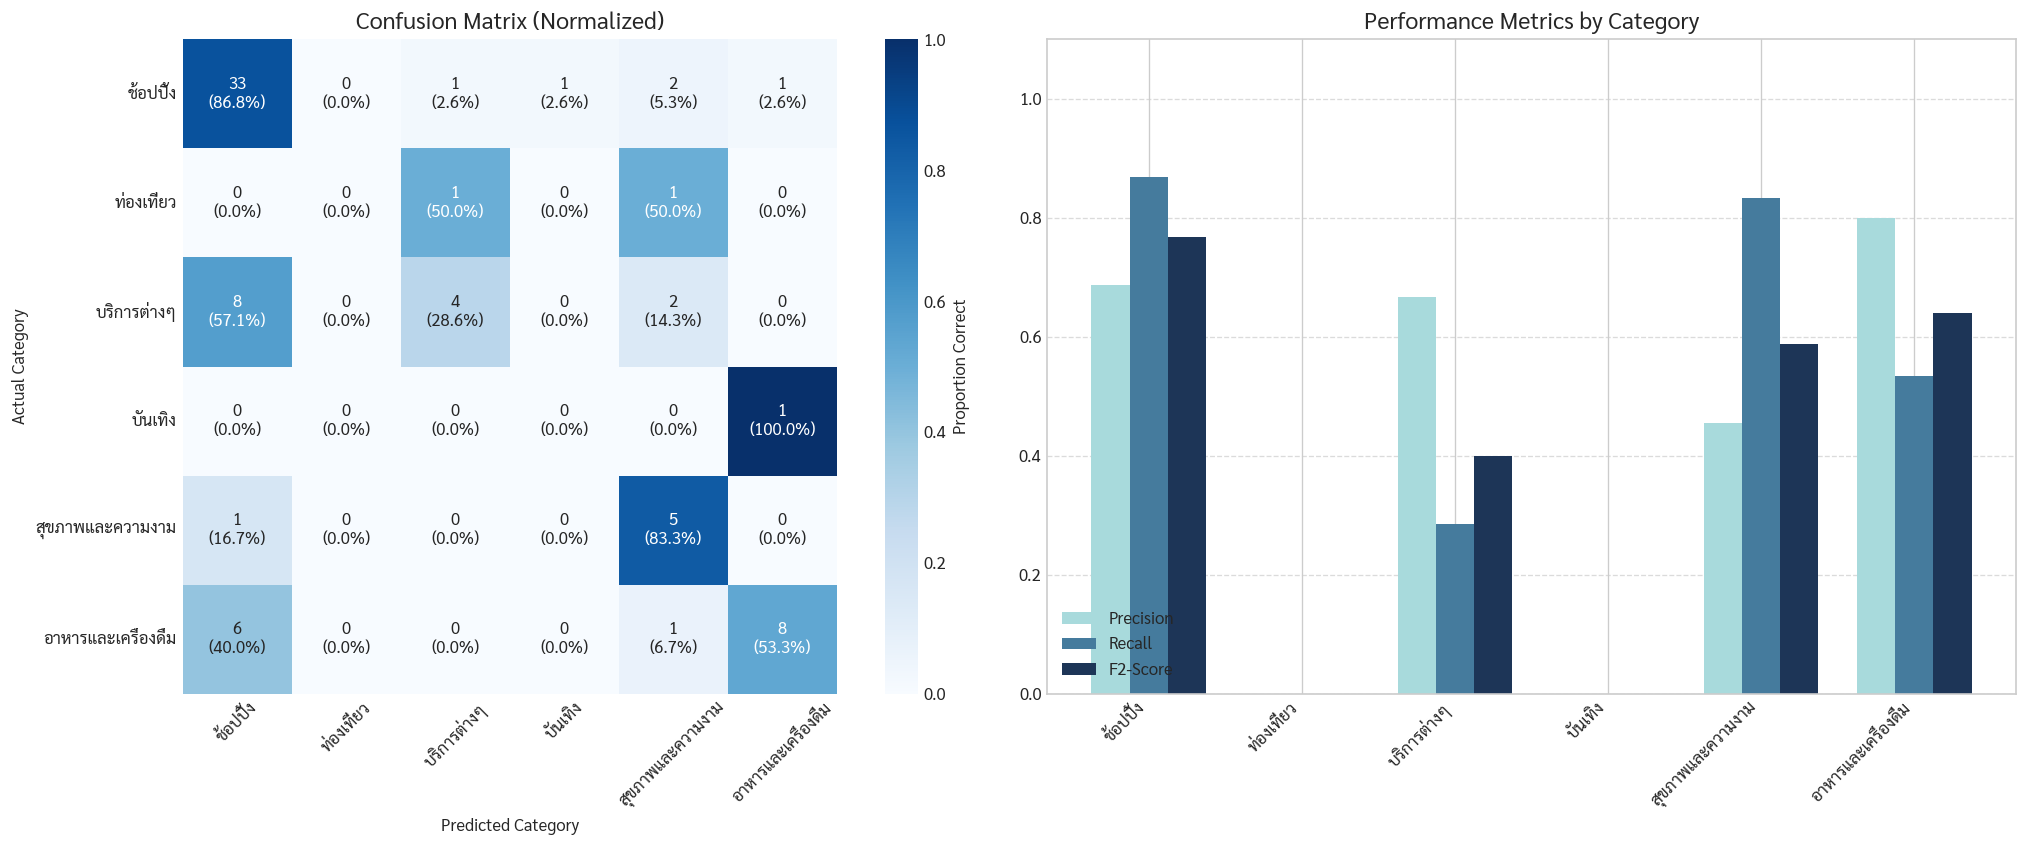


📈 2. CONFIDENCE SCORE DISTRIBUTION
---------------------------------------------


/tmp/ipython-input-1260994668.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_cat, labels=categories_order, patch_artist=True,


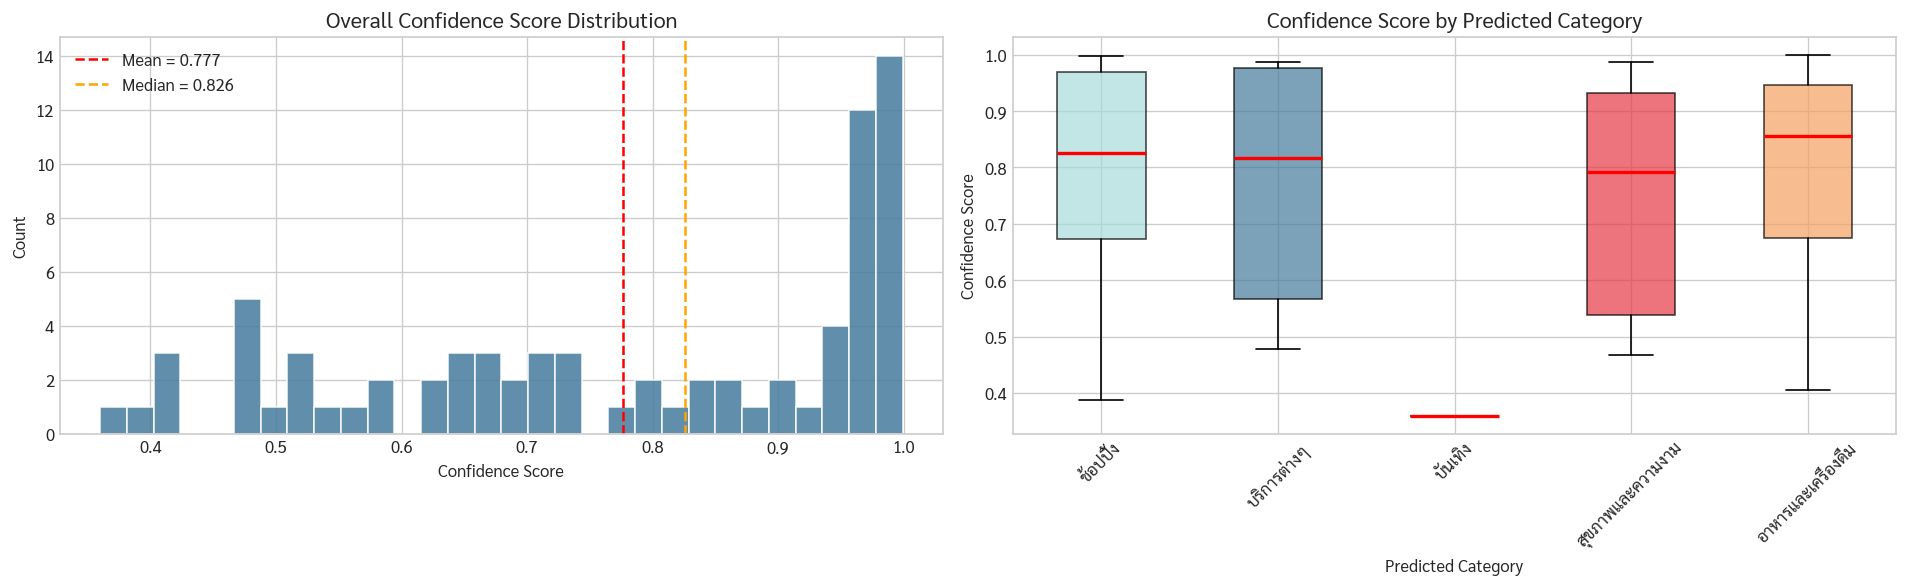

                     count   mean    std    min    25%    50%    75%    max
Predicted_Category                                                         
ช้อปปิ้ง              48.0  0.795  0.188  0.388  0.673  0.826  0.969  0.998
บริการต่างๆ            6.0  0.768  0.239  0.478  0.566  0.816  0.976  0.987
บันเทิง                1.0  0.360    NaN  0.360  0.360  0.360  0.360  0.360
สุขภาพและความงาม      11.0  0.739  0.214  0.467  0.539  0.791  0.932  0.987
อาหารและเครื่องดื่ม   10.0  0.777  0.223  0.405  0.675  0.855  0.947  0.999
---------------------------------------------

🔍 3. TOP CONFUSED PAIRS
---------------------------------------------------------------------------
Actual Category           | Predicted (Wrongly)       | Count     
---------------------------------------------------------------------------
บริการต่างๆ               > ช้อปปิ้ง                  : 8 cases
อาหารและเครื่องดื่ม       > ช้อปปิ้ง                  : 6 cases
ช้อปปิ้ง                  > สุขภาพและความงาม      

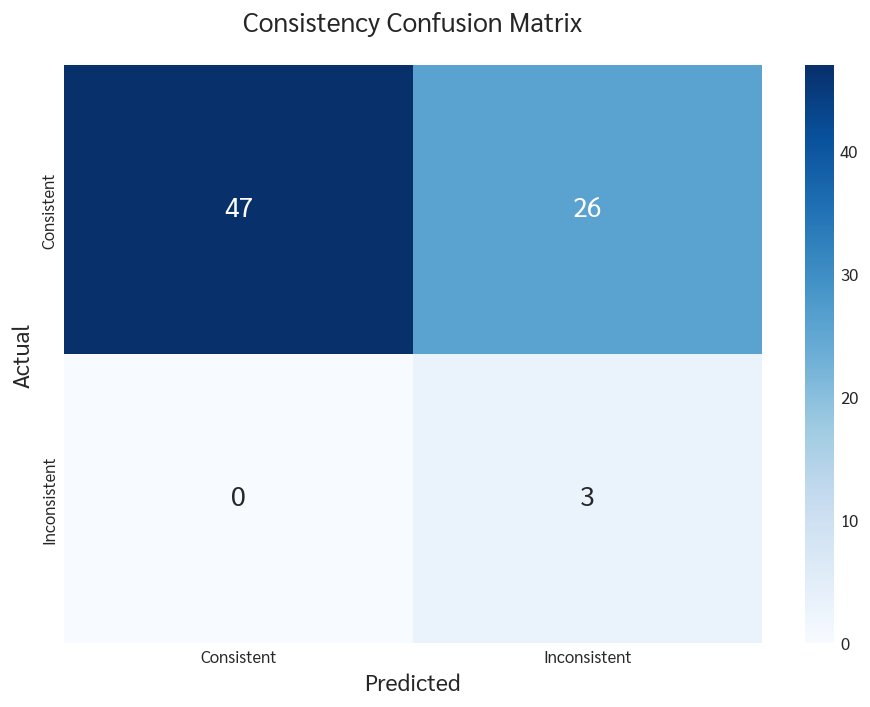

In [ ]:
#Section 6: Evaluation & Visualization

# --- Setup Style ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rc('font', family='Sarabun')
plt.rcParams['figure.dpi'] = 120

# --- Prepare Data ---
y_true = result_df['True_Category']
y_pred = result_df['Predicted_Category']
labels = sorted(list(set(y_true) | set(y_pred)))

print("=" * 60)
print(f"{'MODEL PERFORMANCE EVALUATION REPORT':^60}")
print("=" * 60)

# ----------------------------------------------------------
# PART 1: Executive Summary
# ----------------------------------------------------------
acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
macro_f2 = fbeta_score(y_true, y_pred, beta=2, average='macro', zero_division=0)
weighted_f2 = fbeta_score(y_true, y_pred, beta=2, average='weighted', zero_division=0)

print(f"\n📊 1. EXECUTIVE SUMMARY")
print(f"{'-' * 45}")
print(f"• Total Samples Evaluated:    {len(y_true)}")
print(f"• Global Accuracy:            {acc:.2%}")
print(f"• Macro F1-Score:             {macro_f1:.4f}")
print(f"• Macro F2-Score:             {macro_f2:.4f}")
print(f"• Weighted F1-Score:          {weighted_f1:.4f}")
print(f"• Weighted F2-Score:          {weighted_f2:.4f}")
print(f"{'-' * 45}")

# ----------------------------------------------------------
# PART 2: Confusion Matrix + Metrics per Category
# ----------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Plot A: Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_norm = confusion_matrix(y_true, y_pred, labels=labels, normalize='true')

annot = [
    [f"{count}\n({percent:.1%})" for count, percent in zip(row_c, row_p)]
    for row_c, row_p in zip(cm, cm_norm)
]

sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Proportion Correct'}, ax=ax[0], square=True)
ax[0].set_title("Confusion Matrix (Normalized)", fontsize=14, fontweight='bold')
ax[0].set_ylabel('Actual Category')
ax[0].set_xlabel('Predicted Category')
ax[0].tick_params(axis='x', rotation=45)

# Plot B: Precision / Recall / F1 per Category
precision, recall, f2, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=labels, zero_division=0
)
x = np.arange(len(labels))
width = 0.25

ax[1].bar(x - width, precision, width, label='Precision', color='#a8dadc')
ax[1].bar(x,         recall,    width, label='Recall',    color='#457b9d')
ax[1].bar(x + width, f2,        width, label='F2-Score',  color='#1d3557')

ax[1].set_title("Performance Metrics by Category", fontsize=14, fontweight='bold')
ax[1].set_xticks(x)
ax[1].set_xticklabels(labels, rotation=45, ha='right')
ax[1].set_ylim(0, 1.1)
ax[1].legend(loc='lower left')
ax[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# PART 3: Confidence Score Distribution
# ----------------------------------------------------------
print("\n📈 2. CONFIDENCE SCORE DISTRIBUTION")
print(f"{'-' * 45}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot A: Overall Histogram
axes[0].hist(result_df['Confidence'], bins=30, color='#457b9d', edgecolor='white', alpha=0.85)
axes[0].axvline(result_df['Confidence'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f"Mean = {result_df['Confidence'].mean():.3f}")
axes[0].axvline(result_df['Confidence'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f"Median = {result_df['Confidence'].median():.3f}")
axes[0].set_title("Overall Confidence Score Distribution", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Confidence Score")
axes[0].set_ylabel("Count")
axes[0].legend()

# Plot B: Boxplot per Category
categories_order = sorted(result_df['Predicted_Category'].unique())
data_by_cat = [
    result_df[result_df['Predicted_Category'] == c]['Confidence'].values
    for c in categories_order
]

bp = axes[1].boxplot(data_by_cat, labels=categories_order, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))

colors = ['#a8dadc', '#457b9d', '#1d3557', '#e63946', '#f4a261', '#2a9d8f']
for patch, color in zip(bp['boxes'], colors[:len(categories_order)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title("Confidence Score by Predicted Category", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Predicted Category")
axes[1].set_ylabel("Confidence Score")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary Stats Table
print(result_df.groupby('Predicted_Category')['Confidence'].describe().round(3).to_string())
print(f"{'-' * 45}")

# ----------------------------------------------------------
# PART 4: Misclassification Analysis
# ----------------------------------------------------------
print("\n🔍 3. TOP CONFUSED PAIRS")
print(f"{'-' * 75}")
print(f"{'Actual Category':<25} | {'Predicted (Wrongly)':<25} | {'Count':<10}")
print(f"{'-' * 75}")

confused_pairs = []
for i, true_label in enumerate(labels):
    for j, pred_label in enumerate(labels):
        if i != j and cm[i, j] > 0:
            confused_pairs.append((cm[i, j], true_label, pred_label))

confused_pairs.sort(key=lambda x: x[0], reverse=True)

if not confused_pairs:
    print(f"{'No errors found! Perfect classification.':^75}")
else:
    for count, true_l, pred_l in confused_pairs[:5]:
        print(f"{true_l:<25} > {pred_l:<25} : {count} cases")

# ----------------------------------------------------------
# PART 5: Consistency Check (Original vs True vs Predicted)
# ----------------------------------------------------------
result_df['Actual_Is_Consistent'] = (
    result_df['Original_Category'] == result_df['True_Category']
).astype(int)
result_df['Predicted_Is_Consistent'] = (
    result_df['Original_Category'] == result_df['Predicted_Category']
).astype(int)

y_true_c = result_df['Actual_Is_Consistent']
y_pred_c = result_df['Predicted_Is_Consistent']

acc_c       = accuracy_score(y_true_c, y_pred_c)
weighted_f1_c = f1_score(y_true_c, y_pred_c, average='weighted', zero_division=0)
weighted_f2_c = fbeta_score(y_true_c, y_pred_c, beta=2, average='weighted', zero_division=0)

print(f"\n✅ 4. CONSISTENCY CHECK SUMMARY")
print(f"{'-' * 45}")
print(f"• Accuracy:           {acc_c:.2%}")
print(f"• Weighted F1-Score:  {weighted_f1_c:.4f}")
print(f"• Weighted F2-Score:  {weighted_f2_c:.4f}")
print(f"{'-' * 45}")

label_names = ['Consistent', 'Inconsistent']
cm_c = confusion_matrix(y_true_c, y_pred_c, labels=[1, 0])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_c, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names,
            annot_kws={"size": 16, "weight": "bold"})
plt.title('Consistency Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Actual', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# demo
import gradio as gr
import base64
import os
from PIL import Image
import torch

_ICONS: dict[str, str] = {
    "ช้อปปิ้ง":            "🛍️",
    "ท่องเที่ยว":          "✈️",
    "บริการต่างๆ":         "🔧",
    "บันเทิง":             "🎉",
    "สุขภาพและความงาม":    "💄",
    "อาหารและเครื่องดื่ม":    "🍜",
}

_CATEGORY_LIST: list[str] = list(CATEGORY_MAP.keys())

def _run_model(image_paths: list[str], selected_category: str) -> dict:

    proc_images = image_paths[:4]
    img_tensors = []

    for img_p in proc_images:
        try:
            img = Image.open(img_p).convert("RGB")
            img_tensors.append(preprocess(img).unsqueeze(0))
        except:
            continue

    if not img_tensors:
        return {"error": "ไม่สามารถอ่านรูปภาพได้ กรุณาตรวจสอบไฟล์"}

    img_batch = torch.cat(img_tensors).to(device)

    with torch.no_grad():
        image_features = model.encode_image(img_batch)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        shop_vector = image_features.mean(dim=0, keepdim=True)

        clip_logits = (100.0 * shop_vector @ text_features.T)
        clip_probs = clip_logits.softmax(dim=-1).cpu().numpy()[0]

    category_scores = {cat: 0.0 for cat in CATEGORY_MAP.keys()}
    for idx, sub_name in enumerate(ALL_SUBCATEGORIES):
        parent = SUBCAT_TO_CAT_MAP[sub_name]
        if clip_probs[idx] > category_scores[parent]:
            category_scores[parent] = clip_probs[idx]

    detected_words = []
    for img_p in proc_images[:4]:
        try:
            res = reader.readtext(img_p, detail=0, paragraph=True)
            detected_words.extend(res)
        except:
            pass

    full_text = " ".join(detected_words).lower()

    for cat, keywords in OCR_KEYWORDS.items():
        for kw in keywords:
            if kw in full_text:
                category_scores[cat] += 0.35
                break

    best_cat = max(category_scores, key=category_scores.get)

    best_sub_score = -1
    best_sub = ""
    for idx, sub_name in enumerate(ALL_SUBCATEGORIES):
        if SUBCAT_TO_CAT_MAP[sub_name] == best_cat:
            if clip_probs[idx] > best_sub_score:
                best_sub_score = clip_probs[idx]
                best_sub = sub_name

    predicted_cat = best_cat
    confidence    = category_scores[best_cat]

    return {
        "predicted_category": predicted_cat,
        "confidence":         min(confidence * 100, 100.0),
        "is_consistent":      predicted_cat == selected_category,
    }


def _on_submit(files, dropdown_value: str) -> str:
    selected = dropdown_value.split("  ", 1)[-1].strip() if dropdown_value else ""

    if not files:
        return _ui_alert("warning",
                         "กรุณาอัปโหลดรูปภาพ",
                         "เพิ่มรูปภาพร้านค้าอย่างน้อย 1 รูป (สูงสุด 4 รูป)")
    if not selected:
        return _ui_alert("warning",
                         "กรุณาเลือกประเภทร้านค้า",
                         "เลือกประเภทที่ตรงกับร้านของคุณมากที่สุด")

    paths  = [f.name if hasattr(f, "name") else str(f) for f in files]
    result = _run_model(paths, selected)

    if "error" in result:
        return _ui_alert("error", "เกิดข้อผิดพลาด", result["error"])

    return _ui_result_card(
        is_consistent=result["is_consistent"],
        selected=selected,
        predicted=result["predicted_category"],
        confidence=result["confidence"],
    )


def _on_upload(files) -> str:
    return _ui_thumbnails(files)

def _ui_result_card(is_consistent: bool, selected: str,
                    predicted: str, confidence: float) -> str:
    sel_icon  = _ICONS.get(selected,  "📦")
    pred_icon = _ICONS.get(predicted, "📦")

    if is_consistent:
        accent, a_light, a_border, bar_end = "#16A34A", "#DCFCE7", "#86EFAC", "#4ADE80"
        verdict, verdict_en, icon_char     = "สอดคล้อง", "Consistent", "✓"
        badge_bg, badge_color              = "#DCFCE7", "#15803D"
        sub_msg = (
            "รูปภาพร้านค้า <strong style='color:#15803D'>สอดคล้อง</strong> "
            "กับประเภทที่เลือก สามารถดำเนินการต่อได้"
        )
    else:
        accent, a_light, a_border, bar_end = "#DC2626", "#FEE2E2", "#FCA5A5", "#F87171"
        verdict, verdict_en, icon_char     = "ไม่สอดคล้อง", "Inconsistent", "✕"
        badge_bg, badge_color              = "#FEE2E2", "#B91C1C"
        sub_msg = (
            f"วิเคราะห์แล้วเห็นว่าน่าจะเป็นประเภท "
            f"<strong style='color:#111'>{pred_icon}&thinsp;{predicted}</strong>"
            f" กรุณาตรวจสอบรูปหรือเปลี่ยนประเภทที่เลือก"
        )

    conf_label = "สูง" if confidence >= 70 else ("ปานกลาง" if confidence >= 40 else "ต่ำ")
    conf_pct   = f"{confidence:.1f}%"

    def _mini(label, icon, name, hi):
        bg  = a_light  if hi else "#F9FAFB"
        bdr = a_border if hi else "#E5E7EB"
        lc  = accent   if hi else "#9CA3AF"
        return f"""
<div style="background:{bg};border:1.5px solid {bdr};border-radius:14px;
            padding:18px 10px;text-align:center;">
  <div style="font-size:10px;color:{lc};letter-spacing:1.5px;text-transform:uppercase;
              margin-bottom:10px;font-weight:600;">{label}</div>
  <div style="font-size:30px;margin-bottom:8px;">{icon}</div>
  <div style="font-size:14px;font-weight:700;color:#111827;line-height:1.3;">{name}</div>
</div>"""

    return f"""
<div style="font-family:'Sarabun',sans-serif;background:#fff;
            border:1.5px solid {a_border};border-radius:20px;overflow:hidden;
            box-shadow:0 4px 24px rgba(0,0,0,0.08);
            animation:fadeUp .38s cubic-bezier(.16,1,.3,1);">
<style>@keyframes fadeUp{{from{{opacity:0;transform:translateY(14px)}}to{{opacity:1;transform:none}}}}</style>

<div style="height:4px;background:linear-gradient(90deg,{accent},{bar_end});"></div>

<div style="padding:30px 28px 24px;text-align:center;">
  <div style="display:inline-flex;align-items:center;gap:9px;background:{badge_bg};
              border:1.5px solid {a_border};border-radius:999px;
              padding:6px 18px 6px 8px;margin-bottom:14px;">
    <span style="width:26px;height:26px;background:{accent};border-radius:50%;
                 display:inline-flex;align-items:center;justify-content:center;
                 font-size:13px;font-weight:900;color:#fff;">{icon_char}</span>
    <span style="font-size:17px;font-weight:800;color:{badge_color};">{verdict}</span>
    <span style="font-size:10px;color:#9CA3AF;font-family:monospace;
                 letter-spacing:1.2px;">{verdict_en}</span>
  </div>

  <p style="font-size:14px;color:#6B7280;line-height:1.75;
            margin:0 auto 22px;max-width:400px;">{sub_msg}</p>

  <div style="display:grid;grid-template-columns:1fr 32px 1fr;
              align-items:center;gap:8px;max-width:400px;margin:0 auto;">
    {_mini("ประเภทที่คุณเลือก", sel_icon,  selected,  hi=False)}
    <div style="text-align:center;font-size:16px;color:#D1D5DB;">→</div>
    {_mini("AI วิเคราะห์ได้",   pred_icon, predicted, hi=True)}
  </div>
</div>

<div style="border-top:1px solid #F3F4F6;padding:15px 28px;background:#FAFAFA;">
  <div style="display:flex;justify-content:space-between;
              align-items:center;margin-bottom:7px;">
    <span style="font-size:11px;color:#9CA3AF;letter-spacing:1px;
                 text-transform:uppercase;font-weight:600;">Confidence Score</span>
    <span style="font-size:12px;font-weight:700;color:{accent};background:{a_light};
                 padding:3px 10px;border-radius:6px;border:1px solid {a_border};">
      {conf_pct}&ensp;·&ensp;{conf_label}
    </span>
  </div>
  <div style="background:#E5E7EB;border-radius:999px;height:6px;overflow:hidden;">
    <div style="width:{conf_pct};height:100%;border-radius:999px;
                background:linear-gradient(90deg,{accent},{bar_end});"></div>
  </div>
</div>
</div>"""


def _ui_alert(kind: str, title: str, body: str) -> str:
    cfg = {
        "warning": ("#F7941D", "#FFF7ED", "#FED7AA", "⚠"),
        "error":   ("#DC2626", "#FEF2F2", "#FECACA", "✕"),
    }
    color, bg, border, icon = cfg.get(kind, ("#6B7280", "#F9FAFB", "#E5E7EB", "•"))
    return f"""
<div style="font-family:'Sarabun',sans-serif;background:{bg};
            border:1.5px solid {border};border-left:4px solid {color};
            border-radius:12px;padding:18px 22px;
            display:flex;align-items:flex-start;gap:14px;">
  <span style="font-size:20px;color:{color};flex-shrink:0;margin-top:1px;">{icon}</span>
  <div>
    <div style="font-weight:700;font-size:15px;color:#111827;margin-bottom:4px;">{title}</div>
    <div style="font-size:13px;color:#6B7280;line-height:1.6;">{body}</div>
  </div>
</div>"""


def _ui_empty() -> str:
    return """
<div style="font-family:'Sarabun',sans-serif;text-align:center;padding:46px 24px;
            color:#D1D5DB;background:#F9FAFB;border:2px dashed #E5E7EB;border-radius:20px;">
  <div style="font-size:34px;margin-bottom:10px;">🔍</div>
  <div style="font-size:15px;font-weight:600;color:#9CA3AF;">ผลการวิเคราะห์จะปรากฏที่นี่</div>
  <div style="font-size:13px;margin-top:5px;color:#D1D5DB;">
    อัปโหลดรูป → เลือกประเภท → กดวิเคราะห์
  </div>
</div>"""


def _ui_thumbnails(files) -> str:
    if not files:
        return ""
    cards = ""
    for f in files[:4]:
        path = f.name if hasattr(f, "name") else str(f)
        try:
            with open(path, "rb") as fh:
                b64 = base64.b64encode(fh.read()).decode()
            ext  = os.path.splitext(path)[1].lower().lstrip(".")
            mime = "jpeg" if ext in ("jpg", "jpeg") else ext
            cards += f"""
<div style="width:86px;height:86px;flex-shrink:0;border-radius:10px;overflow:hidden;
            border:1.5px solid #FED7AA;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <img src='data:image/{mime};base64,{b64}'
       style='width:100%;height:100%;object-fit:cover;display:block;'>
</div>"""
        except Exception:
            pass

    n = min(len(files), 4)
    return f"""
<div style="margin-top:10px;">
  <div style="font-size:11px;color:#9CA3AF;font-weight:600;
              letter-spacing:1px;text-transform:uppercase;margin-bottom:8px;">
    {n} รูปที่เลือก
  </div>
  <div style="display:flex;gap:10px;flex-wrap:wrap;">{cards}</div>
</div>"""


# css
_CSS = """
@import url('https://fonts.googleapis.com/css2?family=Sarabun:wght@400;600;700;800&display=swap');

*, *::before, *::after { box-sizing: border-box; }

body, .gradio-container {
    background: #F5F5F5 !important;
    font-family: 'Sarabun', sans-serif !important;
    color: #111827 !important;
}
.gradio-container {
    max-width: 700px !important;
    margin: 0 auto !important;
    padding: 0 16px 48px !important;
}
footer { display: none !important; }

/* Upload zone */
[data-testid="file-upload"], .upload-container {
    background: #FFF7ED !important;
    border: 2px dashed #FED7AA !important;
    border-radius: 14px !important;
    transition: border-color .2s !important;
    color: #92400E !important;
}
[data-testid="file-upload"]:hover {
    border-color: #F7941D !important;
    background: #FEF3E6 !important;
}

/* Dropdown */
select, input[type="text"] {
    background: #fff !important;
    border: 1.5px solid #E5E7EB !important;
    border-radius: 12px !important;
    color: #111827 !important;
    font-family: 'Sarabun', sans-serif !important;
    font-size: 15px !important;
}
select:focus, input:focus {
    border-color: #F7941D !important;
    outline: none !important;
    box-shadow: 0 0 0 3px rgba(247,148,29,0.12) !important;
}

/* Button */
button.primary, button[variant="primary"] {
    background: linear-gradient(135deg, #F7941D, #FFBA5A) !important;
    color: #fff !important;
    font-family: 'Sarabun', sans-serif !important;
    font-weight: 800 !important;
    font-size: 16px !important;
    border: none !important;
    border-radius: 12px !important;
    padding: 14px 28px !important;
    width: 100% !important;
    box-shadow: 0 4px 14px rgba(247,148,29,0.35) !important;
    transition: transform .15s, box-shadow .15s !important;
}
button.primary:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 8px 24px rgba(247,148,29,0.45) !important;
}

/* Labels */
label > span:first-child, .gr-block-label > span {
    font-size: 11px !important;
    font-weight: 700 !important;
    letter-spacing: 1.2px !important;
    text-transform: uppercase !important;
    color: #9CA3AF !important;
}

::-webkit-scrollbar { width: 4px; }
::-webkit-scrollbar-thumb { background: #FED7AA; border-radius: 2px; }
"""


# gradio layout
with gr.Blocks(css=_CSS, title="TrueMoney · ตรวจสอบประเภทร้านค้า") as demo:

    # Header
    gr.HTML("""
<div style="padding:36px 0 26px;text-align:center;
            border-bottom:1px solid #F3F4F6;margin-bottom:26px;">
  <div style="display:inline-flex;align-items:center;gap:8px;
              background:#FFF7ED;border:1.5px solid #FED7AA;
              border-radius:999px;padding:5px 16px 5px 8px;margin-bottom:18px;
              box-shadow:0 1px 4px rgba(247,148,29,0.12);">
    <div style="width:28px;height:28px;
                background:linear-gradient(135deg,#F7941D,#FFBA5A);
                border-radius:50%;display:flex;align-items:center;
                justify-content:center;font-size:14px;
                box-shadow:0 2px 6px rgba(247,148,29,0.35);">💳</div>
    <span style="font-family:monospace;font-size:10px;font-weight:700;
                 letter-spacing:1.8px;color:#EA6C00;text-transform:uppercase;">
      TrueMoney
    </span>
  </div>
  <h1 style="font-size:23px;font-weight:800;color:#111827;
             margin:0 0 8px;line-height:1.25;">
    ตรวจสอบความสอดคล้องของร้านค้า
  </h1>
  <p style="font-size:14px;color:#6B7280;margin:0;line-height:1.7;
            max-width:340px;margin-inline:auto;">
    อัปโหลดรูปภาพร้านค้าและเลือกประเภท<br>ระบบจะตรวจสอบและแสดงผลทันที
  </p>
</div>
""")

    # Step 1
    gr.HTML("""
<div style="display:flex;align-items:center;gap:10px;margin-bottom:10px;">
  <div style="width:28px;height:28px;flex-shrink:0;
              background:linear-gradient(135deg,#F7941D,#FFBA5A);
              border-radius:50%;display:flex;align-items:center;justify-content:center;
              font-size:12px;font-weight:800;color:#fff;
              box-shadow:0 2px 6px rgba(247,148,29,0.35);">1</div>
  <span style="font-size:15px;font-weight:700;color:#111827;">อัปโหลดรูปภาพร้านค้า</span>
  <span style="font-size:12px;color:#9CA3AF;">(1–4 รูป · jpg, png, webp)</span>
</div>
""")

    images_input = gr.File(
        file_count="multiple",
        file_types=[".jpg", ".jpeg", ".png", ".webp"],
        label="คลิกเพื่อเลือกไฟล์  หรือ  ลากไฟล์มาวางที่นี่",
        height=148,
    )
    preview_area = gr.HTML(value="")

    # Step 2
    gr.HTML("""
<div style="display:flex;align-items:center;gap:10px;margin:24px 0 10px;">
  <div style="width:28px;height:28px;flex-shrink:0;
              background:linear-gradient(135deg,#F7941D,#FFBA5A);
              border-radius:50%;display:flex;align-items:center;justify-content:center;
              font-size:12px;font-weight:800;color:#fff;
              box-shadow:0 2px 6px rgba(247,148,29,0.35);">2</div>
  <span style="font-size:15px;font-weight:700;color:#111827;">เลือกประเภทร้านค้าของคุณ</span>
</div>
""")

    category_input = gr.Dropdown(
        choices=[f"{_ICONS.get(c, '📦')}  {c}" for c in _CATEGORY_LIST],
        value=None,
        label="ประเภทร้านค้า (Selected Category)",
        allow_custom_value=False,
    )

    gr.HTML('<div style="height:20px;"></div>')

    submit_btn = gr.Button(
        "วิเคราะห์ความสอดคล้อง",
        variant="primary",
        size="lg",
    )

    gr.HTML('<div style="height:22px;"></div>')

    result_area = gr.HTML(value=_ui_empty())

    gr.HTML("""
<div style="margin-top:26px;padding:12px 16px;background:#F9FAFB;
            border:1px solid #E5E7EB;border-radius:12px;
            font-size:12px;color:#9CA3AF;text-align:center;line-height:1.6;">
  🤖&ensp;<strong style="color:#6B7280;">mCLIP + EasyOCR</strong>
</div>
""")

    images_input.change(fn=_on_upload,  inputs=[images_input],                    outputs=[preview_area])
    submit_btn.click(   fn=_on_submit,  inputs=[images_input, category_input],    outputs=[result_area])

demo.launch(share=True)

/tmp/ipython-input-2427816859.py:346: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=_CSS, title="TrueMoney · ตรวจสอบประเภทร้านค้า") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://04da2caa5ea7456f17.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
